# recount2 — CLAMP robustness across seeds (n=32 000, C2CP)

**Environment:** `clamp-analyses`

Assesses how robust the latent variables (LVs) are across the three independent
CLAMP runs at the largest sample size (n = 32 000, seeds 1/2/3).

Each model comes from `output/recount2_multiplier_imp_fixed/c2cp_subsample_32000_seed_{X}/CLAMPfull_C2CP.rds`
and carries:
- `$Z` — gene-loading matrix (genes × K)
- `$B` — sample-score matrix (K × samples)
- `$summary` — per-LV pathway enrichment table

**Strategy**

LVs are not labelled consistently across runs (order is arbitrary).  
For each pair of models we therefore compute the **absolute Pearson correlation** between
every LV in model A and every LV in model B (using the gene-loading vectors in Z),
then record the **best-match correlation** for each LV (i.e. the maximum over all partners).  
A high best-match correlation means the LV is reproduced faithfully in the other run.

We also assess pathway-level reproducibility by checking which C2CP pathways are
significantly associated (FDR < 0.05) across all three models.

## Libraries

In [1]:
library(data.table)
library(dplyr)
library(tidyr)
library(ggplot2)
library(here)

source(here("config.R"))


Attaching package: ‘dplyr’


The following objects are masked from ‘package:data.table’:

    between, first, last


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


here() starts at /home/msubirana/Documents/pivlab/clamp-analyses



## Configuration

In [2]:
FDR_CUTOFF   <- 0.05
SAMPLE_SIZE  <- 32000
N_SEEDS      <- 3
output_dir   <- file.path(config$GENERAL$OUTPUT_DIR, "recount2_multiplier_imp_fixed")

model_dirs <- lapply(seq_len(N_SEEDS), function(s) {
    file.path(output_dir, paste0("c2cp_subsample_", SAMPLE_SIZE, "_seed_", s))
})

message("Model directories:")
invisible(lapply(model_dirs, message))

Model directories:

/home/msubirana/Documents/pivlab/clamp-analyses/output/recount2_multiplier_imp_fixed/c2cp_subsample_32000_seed_1

/home/msubirana/Documents/pivlab/clamp-analyses/output/recount2_multiplier_imp_fixed/c2cp_subsample_32000_seed_2

/home/msubirana/Documents/pivlab/clamp-analyses/output/recount2_multiplier_imp_fixed/c2cp_subsample_32000_seed_3



## Load Z matrices (gene loadings)

Read each `CLAMPfull_C2CP/Z.csv` (genes × LVs) using `data.table::fread` for speed.

In [3]:
load_Z <- function(model_dir) {
    z_path <- file.path(model_dir, "CLAMPfull_C2CP", "Z.csv")
    dt     <- fread(z_path)
    genes  <- dt[[1]]
    mat    <- as.matrix(dt[, -1])
    rownames(mat) <- genes
    message(sprintf("  Loaded Z: %d genes x %d LVs  [%s]",
                    nrow(mat), ncol(mat), basename(model_dir)))
    mat
}

message("Loading Z matrices...")
Z_list <- lapply(model_dirs, load_Z)
names(Z_list) <- paste0("seed_", seq_len(N_SEEDS))

# Verify gene sets are identical across models
all_same_genes <- all(sapply(Z_list[-1], function(z) {
    identical(rownames(z), rownames(Z_list[[1]]))
}))
message("\nGene sets identical across models: ", all_same_genes)

K_per_seed <- sapply(Z_list, ncol)
cat("\nK per seed:\n")
print(K_per_seed)

Loading Z matrices...



  Loaded Z: 6000 genes x 875 LVs  [c2cp_subsample_32000_seed_1]

  Loaded Z: 6000 genes x 911 LVs  [c2cp_subsample_32000_seed_2]

  Loaded Z: 6000 genes x 946 LVs  [c2cp_subsample_32000_seed_3]


Gene sets identical across models: TRUE




K per seed:
seed_1 seed_2 seed_3 
   875    911    946 


## Pairwise LV robustness

For each pair of models (A, B) we compute:
1. The absolute Pearson correlation matrix between all LVs of A and all LVs of B (using gene-loading vectors in Z).  
   Uses column-standardised matrix multiplication for efficiency.
2. The **best-match correlation** for each LV in A: `max_j |cor(Z_A[,i], Z_B[,j])|`.

In [4]:
# Standardise columns of a matrix (centre + scale).
# Constant columns (sd=0) are set to 0 to avoid NaN.
scale_cols <- function(mat) {
    m   <- colMeans(mat)
    s   <- apply(mat, 2, sd)
    s[s == 0] <- 1
    t((t(mat) - m) / s)
}

# Absolute correlation matrix between columns of Z_A and columns of Z_B.
abs_cor_matrix <- function(Z_A, Z_B) {
    Za <- scale_cols(Z_A)
    Zb <- scale_cols(Z_B)
    abs(crossprod(Za, Zb) / (nrow(Za) - 1))
}

# All seed pairs
pairs <- combn(N_SEEDS, 2, simplify = FALSE)

pair_results <- lapply(pairs, function(p) {
    a <- p[1]; b <- p[2]
    label <- paste0("seed_", a, "_vs_seed_", b)
    message("Computing |cor| matrix for ", label, " ...")

    cor_mat <- abs_cor_matrix(Z_list[[a]], Z_list[[b]])

    # Best-match correlation for each LV in model A (rows)
    best_A <- apply(cor_mat, 1, max)
    # Best-match correlation for each LV in model B (cols)
    best_B <- apply(cor_mat, 2, max)

    message(sprintf("  %s: median best-match = %.3f (A) / %.3f (B)",
                    label, median(best_A), median(best_B)))

    list(
        pair      = label,
        seed_a    = a,
        seed_b    = b,
        cor_mat   = cor_mat,
        best_A    = best_A,
        best_B    = best_B
    )
})
names(pair_results) <- sapply(pair_results, `[[`, "pair")

message("\nDone.")

Computing |cor| matrix for seed_1_vs_seed_2 ...



  seed_1_vs_seed_2: median best-match = 0.516 (A) / 0.503 (B)

Computing |cor| matrix for seed_1_vs_seed_3 ...

  seed_1_vs_seed_3: median best-match = 0.526 (A) / 0.498 (B)

Computing |cor| matrix for seed_2_vs_seed_3 ...

  seed_2_vs_seed_3: median best-match = 0.509 (A) / 0.499 (B)


Done.



## Distribution of best-match correlations

For each model pair, the density of the best-match absolute correlation across LVs.

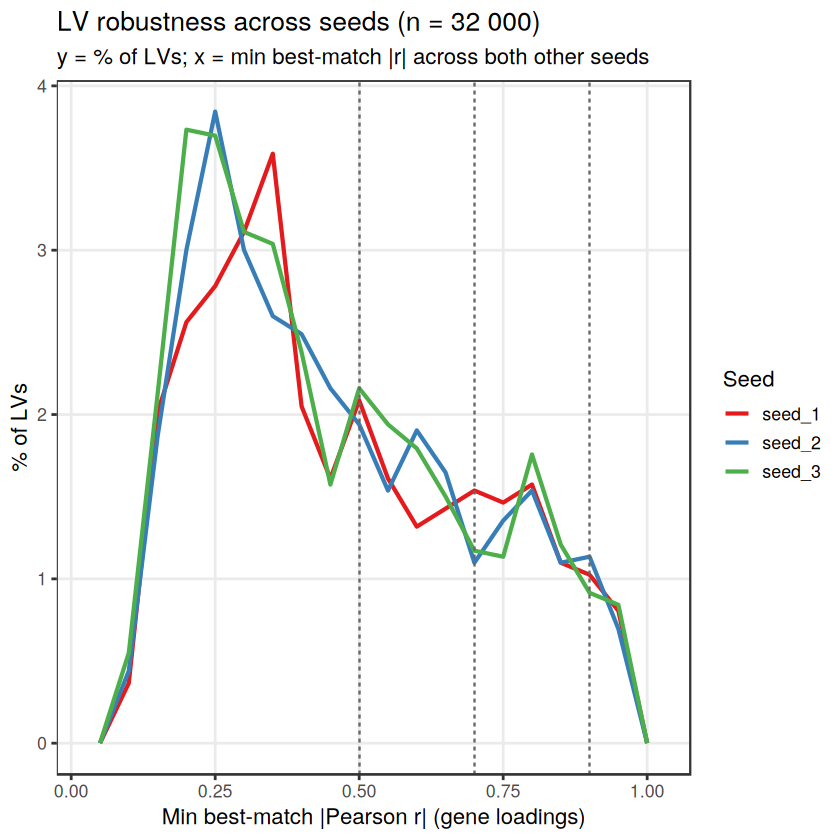

In [5]:
# Build a long data frame: one row per LV per model per pair (used in summary cell below)
best_df <- dplyr::bind_rows(lapply(pair_results, function(res) {
    bind_rows(
        data.frame(pair = res$pair, model = paste0("seed_", res$seed_a), best_match = res$best_A),
        data.frame(pair = res$pair, model = paste0("seed_", res$seed_b), best_match = res$best_B)
    )
}))

# For each LV in each seed: min best-match across both other seeds (worst-case robustness)
robust_all_df <- dplyr::bind_rows(
    data.frame(seed = "seed_1",
               min_match = pmin(pair_results[["seed_1_vs_seed_2"]]$best_A,
                                pair_results[["seed_1_vs_seed_3"]]$best_A)),
    data.frame(seed = "seed_2",
               min_match = pmin(pair_results[["seed_1_vs_seed_2"]]$best_B,
                                pair_results[["seed_2_vs_seed_3"]]$best_A)),
    data.frame(seed = "seed_3",
               min_match = pmin(pair_results[["seed_1_vs_seed_3"]]$best_B,
                                pair_results[["seed_2_vs_seed_3"]]$best_B))
)

# Single-panel plot: % of LVs per bin, one line per seed
p_freq <- ggplot(robust_all_df, aes(x = min_match, colour = seed)) +
    geom_freqpoly(
        aes(y = after_stat(count / sum(count)) * 100),
        binwidth = 0.05, linewidth = 0.9
    ) +
    geom_vline(xintercept = c(0.5, 0.7, 0.9),
               linetype = "dashed", colour = "grey40", linewidth = 0.5) +
    scale_colour_brewer(palette = "Set1") +
    labs(
        title    = "LV robustness across seeds (n = 32 000)",
        subtitle = "y = % of LVs; x = min best-match |r| across both other seeds",
        x        = "Min best-match |Pearson r| (gene loadings)",
        y        = "% of LVs",
        colour   = "Seed"
    ) +
    theme_bw(base_size = 13) +
    theme(panel.grid.minor = element_blank())

print(p_freq)

## CDF of best-match correlations

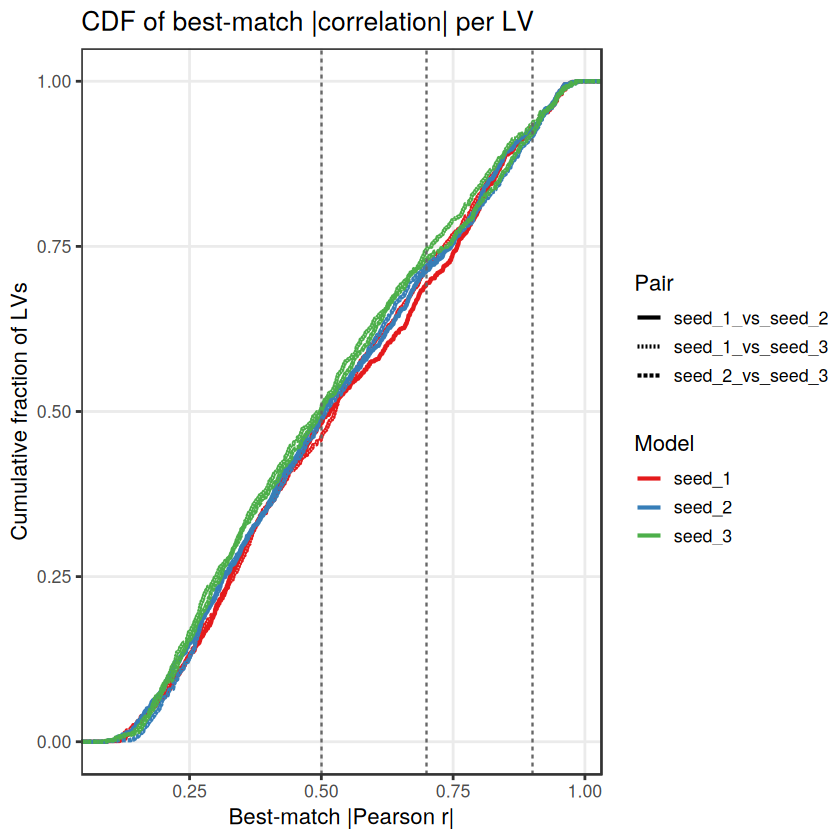

In [6]:
p_cdf <- ggplot(best_df, aes(x = best_match, colour = model, linetype = pair)) +
    stat_ecdf(linewidth = 0.9) +
    geom_vline(xintercept = c(0.5, 0.7, 0.9),
               linetype = "dashed", colour = "grey40", linewidth = 0.5) +
    scale_colour_brewer(palette = "Set1") +
    labs(
        title    = "CDF of best-match |correlation| per LV",
        x        = "Best-match |Pearson r|",
        y        = "Cumulative fraction of LVs",
        colour   = "Model",
        linetype = "Pair"
    ) +
    theme_bw(base_size = 13) +
    theme(panel.grid.minor = element_blank())

print(p_cdf)

## Summary statistics per pair

In [7]:
thresholds <- c(0.5, 0.7, 0.9)

summary_df <- best_df %>%
    dplyr::group_by(pair, model) %>%
    dplyr::summarise(
        n_lvs        = dplyr::n(),
        median_r     = round(median(best_match), 3),
        mean_r       = round(mean(best_match),   3),
        pct_above_50 = round(mean(best_match >= 0.5) * 100, 1),
        pct_above_70 = round(mean(best_match >= 0.7) * 100, 1),
        pct_above_90 = round(mean(best_match >= 0.9) * 100, 1),
        .groups = "drop"
    )

print(summary_df)

# A tibble: 6 × 8
  pair        model n_lvs median_r mean_r pct_above_50 pct_above_70 pct_above_90
  <chr>       <chr> <int>    <dbl>  <dbl>        <dbl>        <dbl>        <dbl>
1 seed_1_vs_… seed…   875    0.516  0.538         51.8         30.6          7.4
2 seed_1_vs_… seed…   911    0.503  0.527         50.5         28.6          7.2
3 seed_1_vs_… seed…   875    0.526  0.532         53.9         28            7  
4 seed_1_vs_… seed…   946    0.498  0.511         49.5         25.5          6.4
5 seed_2_vs_… seed…   911    0.509  0.532         51           28            8.3
6 seed_2_vs_… seed…   946    0.499  0.521         49.9         27            7.9


## Per-LV robustness score (across all three seeds)

For each LV in seed_1, compute the minimum best-match correlation across the two
comparisons (vs seed_2 and vs seed_3).  A high minimum indicates the LV is
consistently reproduced in both other runs.

In [8]:
# Pairs involving seed 1
best_1v2 <- pair_results[["seed_1_vs_seed_2"]]$best_A  # best match in seed_2 for each LV of seed_1
best_1v3 <- pair_results[["seed_1_vs_seed_3"]]$best_A  # best match in seed_3 for each LV of seed_1

robustness_seed1 <- data.frame(
    LV             = colnames(Z_list[["seed_1"]]),
    best_match_s2  = best_1v2,
    best_match_s3  = best_1v3,
    min_match      = pmin(best_1v2, best_1v3)  # worst-case across both comparisons
) %>%
    dplyr::arrange(desc(min_match))

cat("Seed 1 — top 20 most robust LVs (by min best-match across seeds 2 & 3):\n")
print(head(robustness_seed1, 20))

cat("\nSeed 1 — bottom 20 least robust LVs:\n")
print(tail(robustness_seed1, 20))

Seed 1 — top 20 most robust LVs (by min best-match across seeds 2 & 3):
         LV best_match_s2 best_match_s3 min_match
LV110 LV110     0.9723154     0.9719101 0.9719101
LV539 LV539     0.9568494     0.9743756 0.9568494
LV57   LV57     0.9585562     0.9545480 0.9545480
LV35   LV35     0.9543556     0.9595326 0.9543556
LV78   LV78     0.9520631     0.9515802 0.9515802
LV63   LV63     0.9511861     0.9563101 0.9511861
LV656 LV656     0.9498144     0.9572224 0.9498144
LV221 LV221     0.9596361     0.9473618 0.9473618
LV47   LV47     0.9478271     0.9463334 0.9463334
LV848 LV848     0.9452268     0.9682974 0.9452268
LV151 LV151     0.9445094     0.9480712 0.9445094
LV114 LV114     0.9462751     0.9437554 0.9437554
LV549 LV549     0.9433185     0.9434981 0.9433185
LV816 LV816     0.9432457     0.9857788 0.9432457
LV15   LV15     0.9423723     0.9482622 0.9423723
LV860 LV860     0.9416145     0.9580923 0.9416145
LV777 LV777     0.9378015     0.9631762 0.9378015
LV81   LV81     0.9614197   

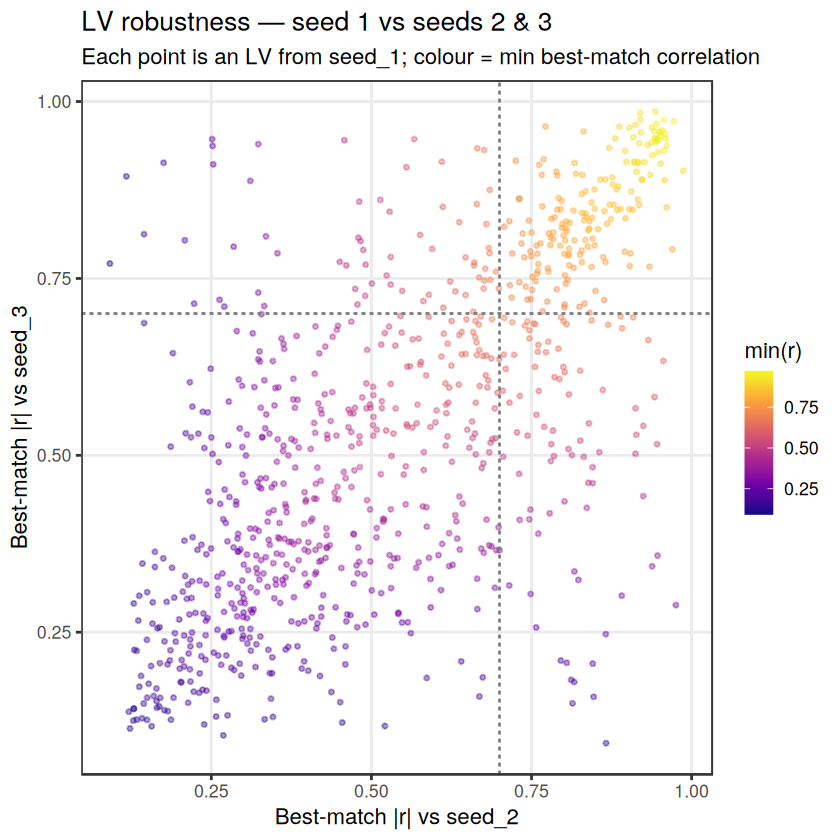

In [9]:
# Scatter: best-match vs seed_2 vs best-match vs seed_3 (one dot per LV of seed_1)
p_scatter <- ggplot(robustness_seed1, aes(x = best_match_s2, y = best_match_s3)) +
    geom_point(aes(colour = min_match), alpha = 0.4, size = 0.8) +
    geom_vline(xintercept = 0.7, linetype = "dashed", colour = "grey50") +
    geom_hline(yintercept = 0.7, linetype = "dashed", colour = "grey50") +
    scale_colour_viridis_c(option = "plasma", name = "min(r)") +
    labs(
        title    = "LV robustness — seed 1 vs seeds 2 & 3",
        subtitle = "Each point is an LV from seed_1; colour = min best-match correlation",
        x        = "Best-match |r| vs seed_2",
        y        = "Best-match |r| vs seed_3"
    ) +
    theme_bw(base_size = 13) +
    theme(panel.grid.minor = element_blank())

print(p_scatter)

## Pathway-level reproducibility

For each model, collect the pathways significantly associated with at least one LV
(FDR < 0.05).  Count in how many of the three models each pathway appears.

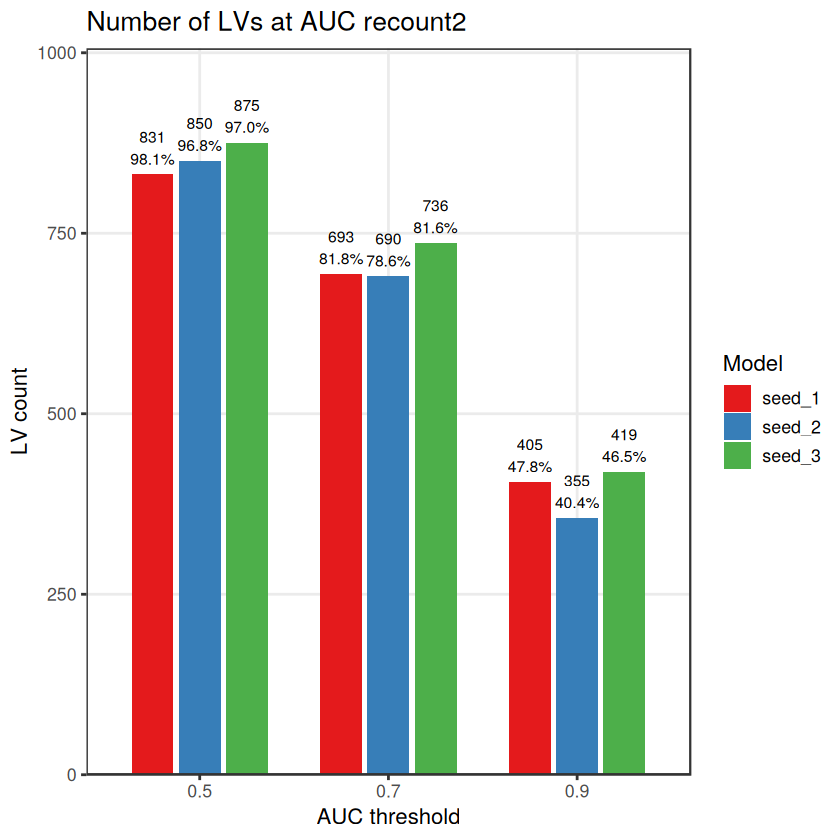

In [16]:
# Max AUC per LV per seed (best pathway match for each LV)
load_lv_auc <- function(model_dir, seed_label) {
    df <- fread(file.path(model_dir, "CLAMPfull_C2CP", "summary.csv"))
    df %>%
        dplyr::group_by(LV) %>%
        dplyr::summarise(max_auc = max(AUC, na.rm = TRUE), .groups = "drop") %>%
        dplyr::mutate(seed = seed_label)
}

auc_df <- dplyr::bind_rows(
    mapply(load_lv_auc, model_dirs, paste0("seed_", seq_len(N_SEEDS)), SIMPLIFY = FALSE)
)

# Count LVs above each threshold per seed
auc_counts <- dplyr::bind_rows(lapply(c(0.5, 0.7, 0.9), function(thr) {
    auc_df %>%
        dplyr::group_by(seed) %>%
        dplyr::summarise(
            n_lvs   = sum(max_auc > thr),
            pct_lvs = round(mean(max_auc > thr) * 100, 1),
            .groups = "drop"
        ) %>%
        dplyr::mutate(threshold = factor(thr))
}))

p_auc <- ggplot(auc_counts, aes(x = threshold, y = n_lvs, fill = seed)) +
    geom_col(position = position_dodge(0.75), width = 0.65) +
    geom_text(aes(label = sprintf("%d\n%.1f%%", n_lvs, pct_lvs)),
              position = position_dodge(0.75), vjust = -0.3, size = 3.2) +
    scale_y_continuous(expand = expansion(mult = c(0, 0.15))) +
    scale_fill_brewer(palette = "Set1", name = "Model") +
    labs(
        title = "Number of LVs at AUC recount2",
        x     = "AUC threshold",
        y     = "LV count"
    ) +
    theme_bw(base_size = 13) +
    theme(panel.grid.minor = element_blank())

print(p_auc)

## LV quality: number of LVs above AUC thresholds across seeds

For each seed, counts how many LVs have a max AUC (across all tested pathways) above
0.5, 0.7, and 0.9. Shows whether the three runs yield a comparable number of
biologically interpretable LVs.

In [11]:
load_sig_pathways <- function(model_dir, fdr_cutoff = 0.05) {
    csv_path <- file.path(model_dir, "CLAMPfull_C2CP", "summary.csv")
    df       <- fread(csv_path)
    unique(df$pathway[df$FDR < fdr_cutoff])
}

sig_pathways <- lapply(seq_len(N_SEEDS), function(s) {
    pw <- load_sig_pathways(model_dirs[[s]], FDR_CUTOFF)
    message(sprintf("Seed %d: %d significant pathways (FDR < %.2f)", s, length(pw), FDR_CUTOFF))
    pw
})
names(sig_pathways) <- paste0("seed_", seq_len(N_SEEDS))

# Count across how many seeds each pathway appears
all_pathways <- unique(unlist(sig_pathways))
pw_counts <- data.frame(
    pathway  = all_pathways,
    n_models = sapply(all_pathways, function(pw) {
        sum(sapply(sig_pathways, function(s) pw %in% s))
    })
)

pw_count_tbl <- table(pw_counts$n_models)
cat("\nNumber of pathways significant in exactly N models:\n")
print(pw_count_tbl)

cat(sprintf("\nTotal unique pathways found in >= 1 model : %d\n", nrow(pw_counts)))
cat(sprintf("Pathways significant in all 3 models      : %d\n",
            sum(pw_counts$n_models == 3)))
cat(sprintf("Pathways significant in >= 2 models        : %d\n",
            sum(pw_counts$n_models >= 2)))

Seed 1: 535 significant pathways (FDR < 0.05)

Seed 2: 463 significant pathways (FDR < 0.05)

Seed 3: 517 significant pathways (FDR < 0.05)




Number of pathways significant in exactly N models:

  1   2   3 
450 270 175 

Total unique pathways found in >= 1 model : 895
Pathways significant in all 3 models      : 175
Pathways significant in >= 2 models        : 445


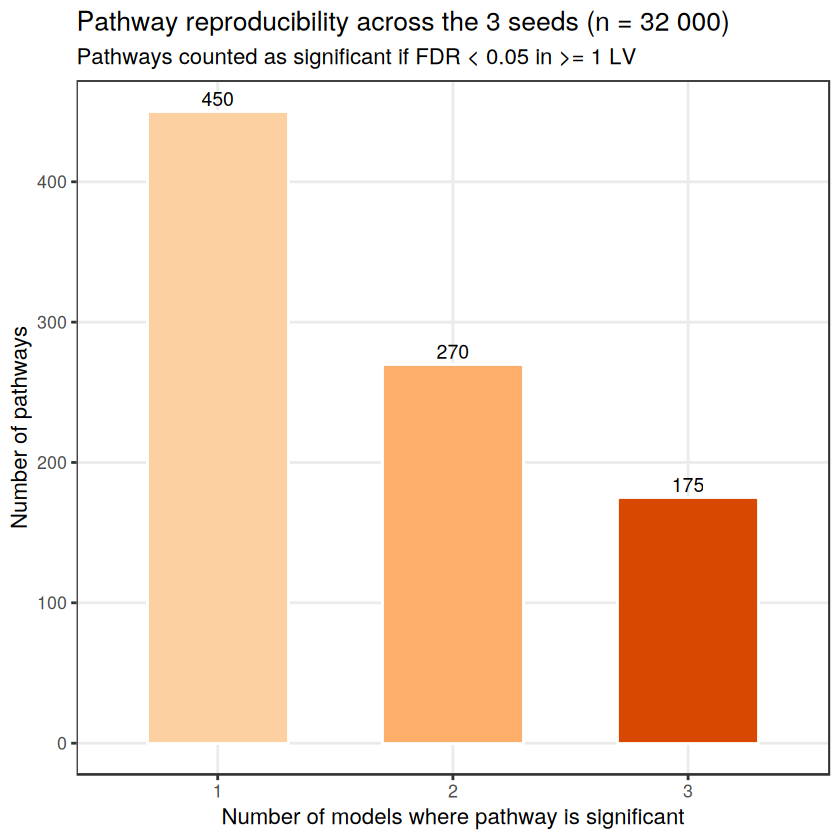

In [12]:
# Bar chart: reproducibility of significant pathways
pw_bar_df <- as.data.frame(pw_count_tbl) %>%
    dplyr::rename(n_models = Var1, n_pathways = Freq) %>%
    dplyr::mutate(n_models = as.integer(as.character(n_models)))

p_pw_bar <- ggplot(pw_bar_df, aes(x = factor(n_models), y = n_pathways,
                                  fill = factor(n_models))) +
    geom_col(colour = "white", width = 0.6) +
    geom_text(aes(label = n_pathways), vjust = -0.4, size = 4) +
    scale_fill_manual(
        values = c("1" = "#FDD0A2", "2" = "#FDAE6B", "3" = "#D94801"),
        guide  = "none"
    ) +
    labs(
        title    = "Pathway reproducibility across the 3 seeds (n = 32 000)",
        subtitle = paste0("Pathways counted as significant if FDR < ", FDR_CUTOFF,
                          " in >= 1 LV"),
        x        = "Number of models where pathway is significant",
        y        = "Number of pathways"
    ) +
    theme_bw(base_size = 13) +
    theme(panel.grid.minor = element_blank())

print(p_pw_bar)

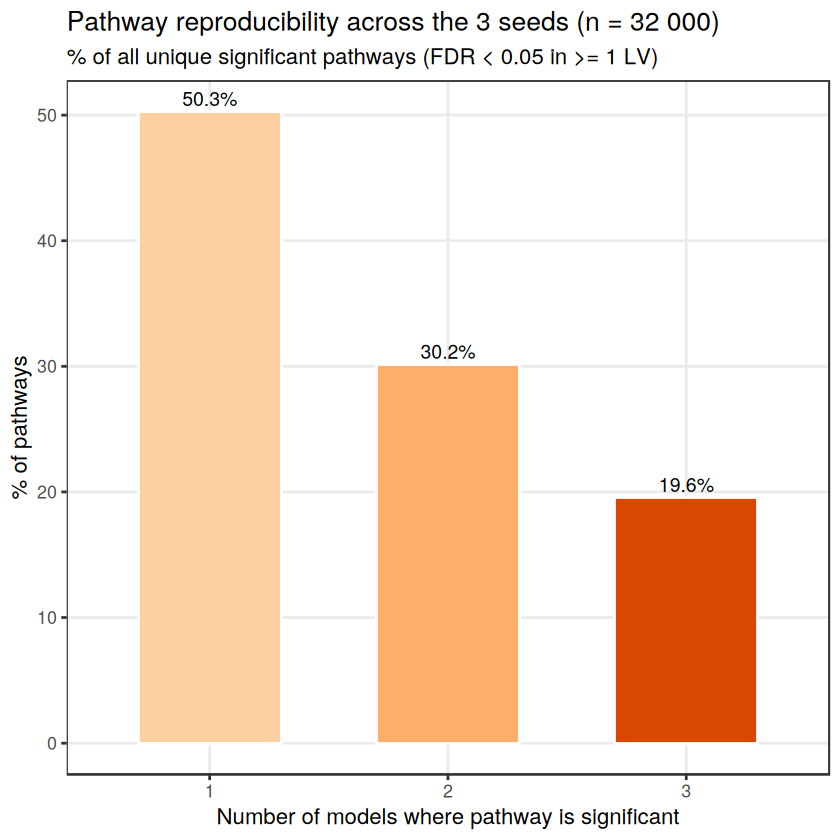

In [13]:
pw_bar_pct_df <- pw_bar_df %>%
    dplyr::mutate(pct = n_pathways / sum(n_pathways) * 100)

p_pw_bar_pct <- ggplot(pw_bar_pct_df, aes(x = factor(n_models), y = pct,
                                           fill = factor(n_models))) +
    geom_col(colour = "white", width = 0.6) +
    geom_text(aes(label = sprintf("%.1f%%", pct)), vjust = -0.4, size = 4) +
    scale_fill_manual(
        values = c("1" = "#FDD0A2", "2" = "#FDAE6B", "3" = "#D94801"),
        guide  = "none"
    ) +
    labs(
        title    = "Pathway reproducibility across the 3 seeds (n = 32 000)",
        subtitle = paste0("% of all unique significant pathways (FDR < ", FDR_CUTOFF, " in >= 1 LV)"),
        x        = "Number of models where pathway is significant",
        y        = "% of pathways"
    ) +
    theme_bw(base_size = 13) +
    theme(panel.grid.minor = element_blank())

print(p_pw_bar_pct)